# PCA Workshop: PFAS Concentrations

This notebook walks through loading, cleaning, and analyzing PFAS concentration data using PCA.

**File needed:** `water_grab_samples_matt_dunn_cape_cod.csv`.


## 0. Setup

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D


## 1. Load the dataset

In [9]:
# Read in the data
path = 'water_grab_samples_matt_dunn_cape_cod.csv'
df = pd.read_csv(path)
df.head(15)


,Site,PFPrA (ng/L),PFBA (ng/L),PFPeA (ng/L),PFHxA (ng/L),PFHpA (ng/L),PFOA (ng/L),PFNA (ng/L),PFDA (ng/L),PFUdA (ng/L),...,FHxSA (ng/L),FHpSA (ng/L),FOSA (ng/L),4:2 FTS (ng/L),6:2 FTS (ng/L),8:2 FTS (ng/L),10:2 FTS (ng/L),5:3 FTCA (ng/L),7:3 FTCA (ng/L),PFECHS (ng/L)
0,1-Groundwater,23.6,40.3,86.1,328.1,185.6,546.1,6.6,2.7,<MDL,...,798.6,12.1,58.6,<MDL,99.5,318.3,<MDL,<MDL,<MDL,7.3
1,1-Groundwater,32.3,59.5,111.7,509.7,323.8,835.5,9.6,4.6,4.4,...,1396.6,22.7,128.6,0.2,175.8,581.4,<MDL,<MDL,<MDL,10.3
2,2-River,0.9,4.4,9.7,12.9,7.0,12.8,6.9,<MDL,<MDL,...,7.5,<MDL,<MDL,<MDL,3.2,0.5,<MDL,0.4,<MDL,0.3
3,2-River,2.1,4.8,10.8,13.4,7.4,14.0,6.4,<MDL,<MDL,...,8.8,<MDL,0.2,<MDL,2.1,0.3,<MDL,0.4,<MDL,0.2
4,2-River,1.9,4.6,10.5,14.7,7.3,14.5,7.7,<MDL,<MDL,...,43.1,<MDL,<MDL,<MDL,3.5,<MDL,<MDL,0.3,<MDL,<MDL
5,2-River,1.5,5.2,9.9,12.5,10.2,14.2,6.3,0.2,0.5,...,14.2,<MDL,0.5,0,2.3,0.3,<MDL,0.4,<MDL,0.2
6,2-River,1.6,4.9,11.3,13.2,7.5,17.4,7.0,<MDL,<MDL,...,26.1,<MDL,0.3,0,2.1,0.3,<MDL,0.3,<MDL,0.2
7,2-River,1.5,4.6,10.1,11.9,7.8,14.3,6.3,<MDL,<MDL,...,11.1,<MDL,0.4,0,1.9,0.2,<MDL,0.4,<MDL,0.2
8,3-Estuary,<MDL,4.1,8.4,10.2,5.6,9.9,5.1,<MDL,<MDL,...,3.0,<MDL,0.4,0,1.0,0,<MDL,<MDL,<MDL,0.2
9,3-Estuary,<MDL,3.9,7.9,9.8,5.4,9.6,4.6,<MDL,<MDL,...,4.4,<MDL,0.3,0,0.7,<MDL,<MDL,<MDL,<MDL,0.1


## 2. Clean and prepare
- Keep only rows with more than 70 % data
- Convert `'<MDL>'` to missing (NaN)
- Impute missing values and scale

In [ ]:
# Count '<MDL' strings per column
mdl_count_per_col = df.eq('<MDL').sum()

# Remove columns with more than 30% '<MDL' values
threshold = 0.3 * len(df)
df = df.loc[:, mdl_count_per_col <= threshold]

# Replace remaining '<MDL' with 0
df.replace('<MDL', 0, inplace=True)

# drop 'Site' and Scale features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.drop(columns=['Site']))

[[ 1.8835209   2.10390168  1.84308462  1.65819907  1.87427225  0.47627533
   1.98144723  1.77508247  1.55636751  1.56270453  1.09047359  1.63267369
   1.53651419  1.00030354  2.17820844  2.1257418   1.66845556  1.34235413
   1.65124191  2.00574572]
 [ 3.08523561  2.92736336  3.1155305   3.2263773   3.09587126  2.20469388
   2.76531647  3.14978017  3.28195252  3.27925822  3.49215221  3.24135987
   3.29308879  3.52389805  2.87869882  2.91914566  3.21977525  3.38773483
   3.23032478  3.00528678]
 [-0.36343525 -0.35361674 -0.36547785 -0.36840463 -0.37686371  0.64911719
  -0.17419316 -0.34058704 -0.34258867 -0.36655867 -0.34977055 -0.36628547
  -0.36613452 -0.34141854 -0.39336368 -0.39234788 -0.38380029 -0.36992171
  -0.3417552  -0.32651675]
 [-0.33839952 -0.31823363 -0.36197442 -0.36386576 -0.37179834  0.36104743
   0.02177415 -0.30158853 -0.35342437 -0.36424661 -0.34913468 -0.37009301
  -0.36462687 -0.32315001 -0.39114412 -0.38992897 -0.38042786 -0.36407776
  -0.36452048 -0.35983478]
 [-0

## 3. Run PCA

In [11]:
pca = PCA(n_components=2)
scores = pca.fit_transform(df_scaled)
scores = pd.DataFrame(scores, columns=['PC1', 'PC2'])

## 4. Get explained variability

In [16]:
explained = pca.explained_variance_ratio_
print('Explained variance ratio:', pca.explained_variance_ratio_)


Explained variance ratio: [0.95555325 0.03325472]


## 5. Scores plot (PC1 vs PC2)

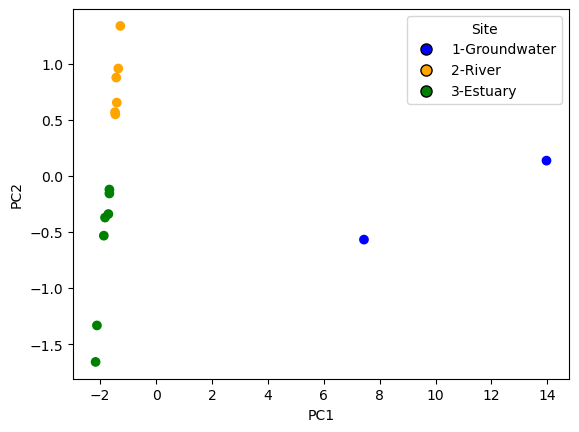

In [ ]:
plt.figure()
plt.scatter(scores['PC1'], scores['PC2'], c=df['Site'].map(
    {'1-Groundwater': 'blue', '2-River': 'orange', '3-Estuary': 'green'}))
plt.xlabel('PC1')
plt.ylabel('PC2')

# Build legend handles from the color map
handles = [
    Line2D([0], [0], marker='o', color='w',
           label=label, markerfacecolor=col, markeredgecolor='k', markersize=8)
    for label, col in {'1-Groundwater': 'blue', '2-River': 'orange', '3-Estuary': 'green'}.items()
]
plt.legend(handles=handles, title='Site', loc='best', frameon=True)

plt.show()


## 6. Biplot (PC1–PC2 with loadings)

In [ ]:
# Loadings for first two PCs
loadings = pd.DataFrame(pca.components_, columns=df.drop(columns=['Site']).columns, index=['PC1', 'PC2'])
loadings = loadings.T  # Transpose for easier plotting
loadings.head(25)


#loadings.sort_values(by='PC1', key=abs, ascending=False).head(25)

# plt.figure()
# for pfas in loadings.index:
#     plt.arrow(0, 0, loadings.loc[pfas, 'PC1'], loadings.loc[pfas, 'PC2'], label=pfas)
#     plt.text(loadings.loc[pfas, 'PC1'], loadings.loc[pfas, 'PC2'], pfas, fontsize=14)
# plt.xlabel('PC1')
# plt.ylabel('PC2')
# plt.show()

,PC1,PC2
PFBA (ng/L),0.228336,-0.029521
PFPeA (ng/L),0.226918,-0.026061
PFHxA (ng/L),0.228358,-0.056920
PFHpA (ng/L),0.228518,-0.047094
PFOA (ng/L),0.228198,-0.066209
PFNA (ng/L),0.145503,0.943478
PFPrS (ng/L),0.217415,0.245162
PFBS (ng/L),0.228623,-0.002401
PFPeS (ng/L),0.228348,-0.036980
L-PFHxS (ng/L),0.228256,-0.050653
